# Lesson 0004: autograd from scratch

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tamnd/soroban/blob/main/lessons/0004-autograd/lesson.ipynb)

Three lessons did the backward pass by hand. Every one used the same move: take the slope coming back from above, multiply by the step's local slope, add it into the input. This notebook builds the machine that does that move, a class called `Value`, and proves it reproduces lessons 0001 and 0002 to the digit with no hand-derived gradient anywhere. The full writeup is in the [lesson README](https://github.com/tamnd/soroban/tree/main/lessons/0004-autograd).

The idea in one animation, the backward walk through the graph of one data point: the slope is seeded at the loss as 1, then flows back through each box, picking up one local factor at a time until it reaches the knobs.

![the backward walk](https://raw.githubusercontent.com/tamnd/soroban/main/lessons/0004-autograd/assets/backward.gif)

The reveal, stated up front: this repo's Go `grad` package has been exactly this engine since lesson 0001. Every Go table you diffed against numpy was already produced by the machine you are about to build.

## 0. A loss is a recipe, and a recipe is a graph

One data point from lesson 0001, `x = 2`, `y = 5`, at `w = 0`, `b = 0`. Its loss is built in four steps, each one operation on the results before it. Filling them in left to right is the [forward pass](https://github.com/tamnd/soroban/blob/main/maths/computation-graph.md).

In [1]:
w, x, b, y = 0.0, 2.0, 0.0, 5.0
wx = w * x
z = wx + b
e = z - y
L = e * e
print("forward:", "wx", wx, " z", z, " e", e, " L", L)
assert (wx, z, e, L) == (0.0, 0.0, -5.0, 25.0)

forward: wx 0.0  z 0.0  e -5.0  L 25.0


## 1. The engine

A `Value` wraps a float, carries a running `.grad`, remembers the nodes it came from, and holds a closure that pushes gradient to those nodes. Each operation builds a new `Value` and wires its backward closure with the operation's local slope. Every closure uses `+=`, not `=`, because a value used in two places collects a slope from each, and the two add. `backward` sorts the graph so each node comes after everything that fed it, seeds the output with 1, and walks the closures in reverse.

In [2]:
import math


class Value:
    def __init__(self, data, prev=()):
        self.data = float(data)
        self.grad = 0.0
        self._prev = tuple(prev)
        self._back = lambda: None

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other))
        def back():
            self.grad += out.grad
            other.grad += out.grad
        out._back = back
        return out

    def __sub__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data - other.data, (self, other))
        def back():
            self.grad += out.grad
            other.grad -= out.grad
        out._back = back
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other))
        def back():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._back = back
        return out

    def __truediv__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data / other.data, (self, other))
        def back():
            self.grad += out.grad / other.data
            other.grad -= self.data / (other.data * other.data) * out.grad
        out._back = back
        return out

    def sq(self):
        out = Value(self.data * self.data, (self,))
        def back():
            self.grad += 2 * self.data * out.grad
        out._back = back
        return out

    def relu(self):
        out = Value(self.data if self.data > 0 else 0.0, (self,))
        def back():
            if self.data > 0:
                self.grad += out.grad
        out._back = back
        return out

    def exp(self):
        d = math.exp(self.data)
        out = Value(d, (self,))
        def back():
            self.grad += d * out.grad
        out._back = back
        return out

    def log(self):
        out = Value(math.log(self.data), (self,))
        def back():
            self.grad += out.grad / self.data
        out._back = back
        return out

    __radd__ = __add__
    __rmul__ = __mul__

    def backward(self):
        topo, visited = [], set()
        def build(n):
            if id(n) in visited:
                return
            visited.add(id(n))
            for p in n._prev:
                build(p)
            topo.append(n)
        build(self)
        self.grad = 1.0
        for n in reversed(topo):
            n._back()


def mean(vs):
    total = vs[0]
    for v in vs[1:]:
        total = total + v
    return total * (1.0 / len(vs))

## 2. The backward walk on one point

Rebuild the same four-box graph with `Value` leaves, call `backward`, and read every slope. They match the hand walk in the README: `dL/de = -10`, `dL/dz = -10`, `dL/db = -10`, `dL/dw = -20`. The `-20` is the [chain rule](https://github.com/tamnd/soroban/blob/main/maths/chain-rule.md) shortcut `2 * e * x = 2 * -5 * 2` unrolled one box at a time.

![the computation graph](https://raw.githubusercontent.com/tamnd/soroban/main/lessons/0004-autograd/assets/graph.png)

In [3]:
w, x, b, y = Value(0.0), Value(2.0), Value(0.0), Value(5.0)
wx = w * x
z = wx + b
e = z - y
L = e.sq()
L.backward()
print("dL/de", e.grad, " dL/dz", z.grad, " dL/db", b.grad, " dL/dw", w.grad)
assert (e.grad, z.grad, b.grad, w.grad) == (-10.0, -10.0, -10.0, -20.0)

dL/de -10.0  dL/dz -10.0  dL/db -10.0  dL/dw -20.0


## 3. Reproduce lesson 0001

No gradient formula in sight: build the four-point loss out of `Value` nodes and call `backward`. Step 1 gives loss 41, dw -35, db -12, exact. The 200-step run, rebuilding the graph each step from fresh leaves, lands on numpy's exact final line.

In [4]:
def loss_0001(w, b, xs, ys):
    return mean([((w * xi + b) - yi).sq() for xi, yi in zip(xs, ys)])

xs, ys = [1.0, 2.0, 3.0, 4.0], [3.0, 5.0, 7.0, 9.0]

w, b = Value(0.0), Value(0.0)
L = loss_0001(w, b, xs, ys)
L.backward()
print("step 1: loss", L.data, " dw", w.grad, " db", b.grad)
assert L.data == 41.0 and w.grad == -35.0 and b.grad == -12.0

wv = bv = 0.0
for step in range(1, 201):
    W, B = Value(wv), Value(bv)
    L = loss_0001(W, B, xs, ys)
    L.backward()
    if step == 2:
        assert abs(L.data - 1.12875) < 1e-9
    if step == 3:
        assert abs(L.data - 0.043271875) < 1e-9
    wv -= 0.05 * W.grad
    bv -= 0.05 * B.grad
print(f"final: w {wv:.6f}  b {bv:.6f}  (numpy got 2.004774, 0.985965)")
assert f"{wv:.6f}" == "2.004774" and f"{bv:.6f}" == "0.985965"

step 1: loss 41.0  dw -35.0  db -12.0
final: w 2.004774  b 0.985965  (numpy got 2.004774, 0.985965)


## 4. Reproduce lesson 0002

The same engine, no new operation beyond the `relu` it already has, runs the two-neuron hidden layer. Seven step-1 gradients, exact, and a 300-step run that matches numpy's final knobs byte for byte.

In [5]:
def loss_0002(p, xs, ys):
    errs = []
    for xi, yi in zip(xs, ys):
        h1 = (p["w1"] * xi + p["b1"]).relu()
        h2 = (p["w2"] * xi + p["b2"]).relu()
        yhat = p["v1"] * h1 + p["v2"] * h2 + p["c"]
        errs.append((yhat - yi).sq())
    return mean(errs)

xs2, ys2 = [-2.0, -1.0, 1.0, 2.0], [2.0, 1.0, 1.0, 2.0]
p = {"w1": 1.0, "b1": -0.5, "w2": -1.0, "b2": -0.5, "v1": 1.0, "v2": 1.0, "c": 0.0}
order = ("w1", "b1", "w2", "b2", "v1", "v2", "c")

for step in range(1, 301):
    P = {k: Value(v) for k, v in p.items()}
    L = loss_0002(P, xs2, ys2)
    L.backward()
    if step == 1:
        g = tuple(P[k].grad for k in order)
        print("step 1: loss", L.data, " grads", g)
        assert L.data == 0.25
        assert g == (-0.75, -0.5, 0.75, -0.5, -0.5, -0.5, -1.0)
    for k in order:
        p[k] -= 0.1 * P[k].grad
print("final:", {k: round(p[k], 6) for k in order})
assert round(p["c"], 6) == 0.323205 and round(p["w1"], 6) == 1.036709

step 1: loss 0.25  grads (-0.75, -0.5, 0.75, -0.5, -0.5, -0.5, -1.0)
final: {'w1': 1.036709, 'b1': -0.335362, 'w2': -1.036709, 'b2': -0.335362, 'v1': 0.964803, 'v2': 0.964803, 'c': 0.323205}


## 5. Closing lesson 0001's loop

Lesson 0001 opened by measuring a slope with an experiment: nudge a knob, recompute the loss, divide the change. That [finite difference](https://github.com/tamnd/soroban/blob/main/maths/derivative.md) can now be checked against the engine that does the chain rule exactly. They agree to four decimals; the tiny gap is the nudge not being infinitely small.

In [6]:
def loss_at(wv, bv):
    return sum((wv * xi + bv - yi) ** 2 for xi, yi in zip(xs, ys)) / 4

h = 1e-6
num_dw = (loss_at(h, 0) - loss_at(0, 0)) / h
num_db = (loss_at(0, h) - loss_at(0, 0)) / h
print(f"nudge dw ~ {num_dw:.4f} (engine -35)   nudge db ~ {num_db:.4f} (engine -12)")
assert abs(num_dw + 35) < 1e-2 and abs(num_db + 12) < 1e-2

nudge dw ~ -35.0000 (engine -35)   nudge db ~ -12.0000 (engine -12)


## 6. The one rule a hand pass never states: slopes add

When a value feeds two boxes, each sends a slope back, and they add. That is why every closure uses `+=`. The smallest test is `x + x`, whose slope is 2; the overwriting version would read 1. `x * x` is 2x. This is the [accumulation rule](https://github.com/tamnd/soroban/blob/main/maths/computation-graph.md), and forgetting it is the next section's bug.

In [7]:
x = Value(3.0)
(x + x).backward()
print("x+x slope:", x.grad, "(must be 2)")
assert x.grad == 2.0

x = Value(3.0)
(x * x).backward()
print("x*x slope:", x.grad, "(must be 6)")
assert x.grad == 6.0

x+x slope: 2.0 (must be 2)
x*x slope: 6.0 (must be 6)


## 7. Break it on purpose: forget to zero the gradients

Reuse the leaf `Value` objects across steps without resetting `.grad`, and step 1's slopes are still there when step 2 runs. Step 2's dw reads -40.75, the stale -35 plus the correct -5.75, and the descent falls apart into a thrash.

![smooth descent versus the thrash](https://raw.githubusercontent.com/tamnd/soroban/main/lessons/0004-autograd/assets/thrash.png)

never zeroed: [41.0, 1.1288, 26.7588, 50.1518, 9.4808]
zeroed each step: [41.0, 1.1288, 0.0433, 0.0134, 0.0122]


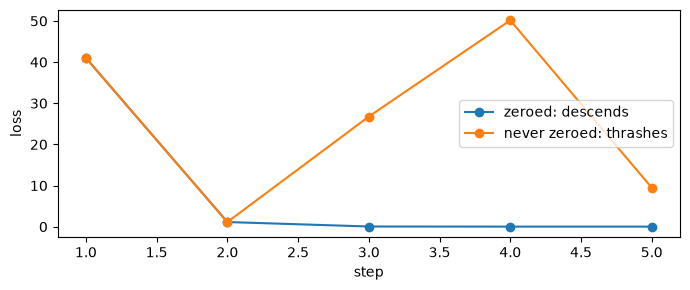

In [8]:
w, b = Value(0.0), Value(0.0)
buggy = []
for step in range(1, 6):
    L = loss_0001(w, b, xs, ys)   # note: w.grad and b.grad are never reset
    L.backward()
    buggy.append(L.data)
    if step == 2:
        assert abs(w.grad + 40.75) < 1e-9   # -35 stale + -5.75 correct
    w.data -= 0.05 * w.grad
    b.data -= 0.05 * b.grad
print("never zeroed:", [round(v, 4) for v in buggy])
assert buggy[2] > buggy[1]   # step 3 climbs: a thrash, not a descent

# The correct run for contrast, gradients fresh each step.
good, wv, bv = [], 0.0, 0.0
for _ in range(5):
    W, B = Value(wv), Value(bv)
    L = loss_0001(W, B, xs, ys)
    L.backward()
    good.append(L.data)
    wv -= 0.05 * W.grad
    bv -= 0.05 * B.grad
print("zeroed each step:", [round(v, 4) for v in good])

import matplotlib.pyplot as plt
plt.figure(figsize=(7, 3))
plt.plot(range(1, 6), good, "o-", label="zeroed: descends")
plt.plot(range(1, 6), buggy, "o-", label="never zeroed: thrashes")
plt.xlabel("step")
plt.ylabel("loss")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Exit test: reproduce a lesson 0003 point

The engine already has `exp` and `log` (added above). Build the [softmax](https://github.com/tamnd/soroban/blob/main/maths/softmax.md) and [cross-entropy](https://github.com/tamnd/soroban/blob/main/maths/cross-entropy.md) of three scores at zero init through `Value` nodes and call `backward`. Every probability is 1/3, the loss is ln 3, and the three score gradients come out `p` minus the one-hot target, the friendly formula from lesson 0003.

In [9]:
z = [Value(0.0), Value(0.0), Value(0.0)]
exps = [zi.exp() for zi in z]
total = exps[0] + exps[1] + exps[2]
probs = [ei / total for ei in exps]
loss = Value(0.0) - probs[1].log()   # cross-entropy, true class is the middle one
loss.backward()
print("loss", loss.data, "(ln 3 =", math.log(3), ")")
print("score grads:", [round(zi.grad, 6) for zi in z])
assert abs(loss.data - math.log(3)) < 1e-12
assert abs(z[0].grad - 1/3) < 1e-12
assert abs(z[1].grad + 2/3) < 1e-12   # 1/3 - 1, probability minus target
assert abs(z[2].grad - 1/3) < 1e-12

loss 1.0986122886681098 (ln 3 = 1.0986122886681098 )
score grads: [0.333333, -0.666667, 0.333333]


## 9. Torch agrees on the same graph

`torch.autograd` is the industrial version of this exact recording and replaying. On the same 0001 graph it returns the same loss and the same two gradients.

In [10]:
try:
    import torch

    xt = torch.tensor([1.0, 2.0, 3.0, 4.0], dtype=torch.float64)
    yt = torch.tensor([3.0, 5.0, 7.0, 9.0], dtype=torch.float64)
    wt = torch.zeros(1, dtype=torch.float64, requires_grad=True)
    bt = torch.zeros(1, dtype=torch.float64, requires_grad=True)
    tl = ((wt * xt + bt - yt) ** 2).mean()
    tl.backward()
    print("torch: loss", tl.item(), " dw", wt.grad.item(), " db", bt.grad.item())
    assert tl.item() == 41.0 and wt.grad.item() == -35.0 and bt.grad.item() == -12.0
    print("torch agrees with the engine on the same graph")
except ImportError:
    print("torch not installed, skipping (Colab has it preinstalled)")

torch: loss 41.0  dw -35.0  db -12.0
torch agrees with the engine on the same graph


## Exercises

1. Build `a + a` and confirm its slope is 2. How many arrows leave the leaf, and which rule turns two 1s into a 2?
2. Predict the slope of `(x * x) * x` at `x = 2` before running it. This is x^3; the engine accumulates the slopes from x's three uses. An answer of 4 or 8 means a missing accumulation.
3. Change the multiply closure's `+=` to `=` and find the first thing that breaks. Why does 0001's four-point loss still pass while `x * x` fails?

Worked answers are in the [lesson README](https://github.com/tamnd/soroban/tree/main/lessons/0004-autograd) and asserted in `train.py`. Lesson 0005 leaves regression for language: a bigram table counted over a tiny corpus, the first model whose output is text.